# `braincell.vis` Tutorial

This notebook walks through the `braincell.vis` module end to end:

1. **Quick start** — load a morphology, render it in 2D and 3D.
2. **Layout gallery** — `fan` (default), `stem`, `balloon`, `radial_360`, `projected`.
3. **Styling & themes** — `vis.theme` / `publication_theme`.
4. **Color-by-values** — per-segment scalars on 2D and 3D.
5. **Overlays** — region highlights and locset markers.
6. **Animation** — `plot_movie` for time-varying voltage/Ca.
7. **Trace panels** — `plot_traces` synchronized with the morphology.
8. **Morphometry plots** — dendrogram / topology / Sholl / branch order.
9. **Interactivity** — matplotlib pick/hover via `VisHooks`.
10. **Publication export** — `PublicationTheme` + `save_figure`.
11. **Comparison** — `compare_morphologies` / `compare_values`.

In [ ]:
import os
os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import brainunit as u
import matplotlib.pyplot as plt
import numpy as np

import braincell
from braincell import Branch, Morphology
from braincell import vis

## 1. Quick start

We'll build a small synthetic tree with an explicit soma, one apical
dendrite, one basal dendrite, and one axon. Every branch in BrainCell is
immutable and typed — either via the base `Branch` class or via the
subclass factories (`Soma`, `Dendrite`, `Axon`, …).

In [ ]:
def make_tree() -> Morphology:
    soma = Branch.from_points(
        points=[[0.0, 0.0, 0.0], [20.0, 0.0, 0.0]] * u.um,
        radii=[10.0, 10.0] * u.um,
        type='soma',
    )
    apical = Branch.from_points(
        points=[[20.0, 0.0, 0.0], [20.0, 40.0, 0.0], [20.0, 80.0, 0.0]] * u.um,
        radii=[3.0, 2.0, 1.5] * u.um,
        type='apical_dendrite',
    )
    basal = Branch.from_points(
        points=[[0.0, 0.0, 0.0], [-15.0, -25.0, 0.0]] * u.um,
        radii=[2.0, 1.5] * u.um,
        type='basal_dendrite',
    )
    axon = Branch.from_points(
        points=[[0.0, 0.0, 0.0], [0.0, -30.0, 0.0], [0.0, -60.0, 0.0]] * u.um,
        radii=[1.0, 0.8, 0.6] * u.um,
        type='axon',
    )
    tree = Morphology.from_root(soma, name='soma')
    tree.attach(parent='soma', child_branch=apical, child_name='apical', parent_x=1.0)
    tree.attach(parent='soma', child_branch=basal, child_name='basal', parent_x=1.0)
    tree.attach(parent='soma', child_branch=axon, child_name='axon', parent_x=0.0)
    return tree

tree = make_tree()
print(tree.topo())

soma
├── apical
├── basal
└── axon


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


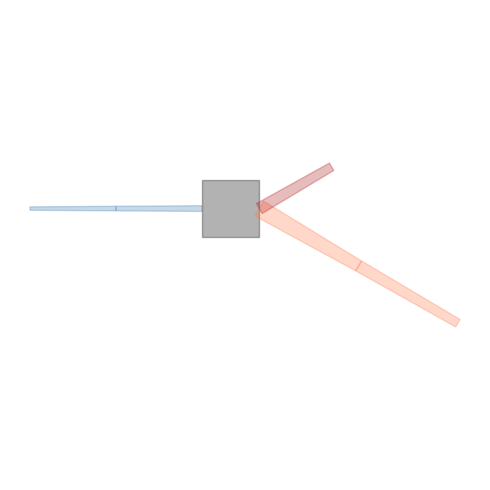

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
vis.plot2d(tree, shape='frustum', ax=ax)
fig.tight_layout()

## 2. Layout gallery

`braincell.vis` ships five layout families:

* `fan` — simple root-centered fan layout (default).
* `stem` — roots grow outward from the soma, children fan out.
* `balloon` — soft radial packing that avoids crossings via a spatial hash.
* `radial_360` — children occupy a full 360° wedge.
* `projected` — raw XY projection, only for morphologies with 3D point data.

`compare_layouts_2d` renders them side by side.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


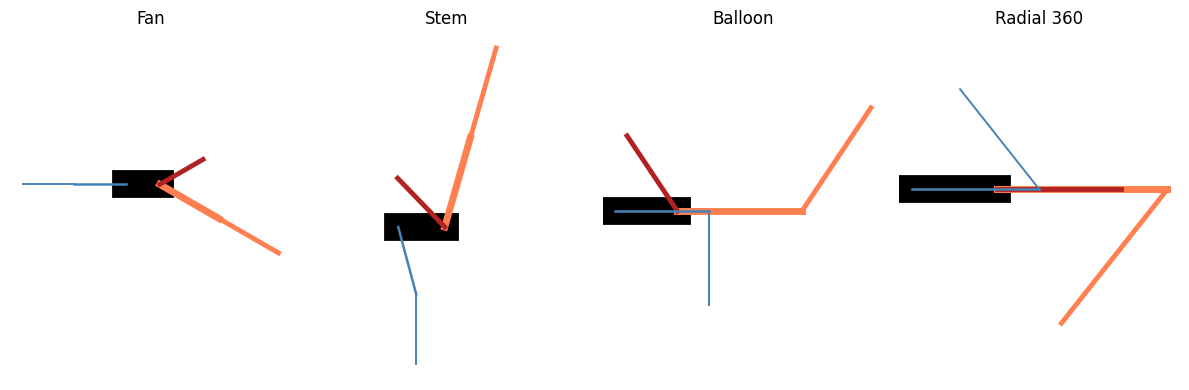

In [ ]:
from braincell.vis.compare2d import compare_layouts_2d

fig, axes = compare_layouts_2d(
    tree,
    layouts=('fan', 'stem', 'balloon', 'radial_360'),
    shape='line',
    figsize=(12, 4),
)
fig.tight_layout()

## 3. Styling and themes

`vis.theme(**overrides)` is a scoped context manager for global defaults
(colours per branch type, alphas, marker sizes). For publication-quality
output there's also `vis.publication_theme()` which flips matplotlib's
`rcParams` on top of the vis defaults — serif font, thicker lines, no grid,
higher contrast palette.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


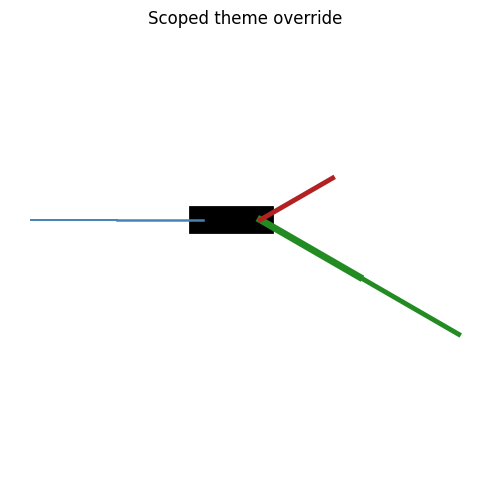

In [ ]:
with vis.theme(branch_type_colors={'apical_dendrite': '#228b22'}):
    fig, ax = plt.subplots(figsize=(5, 5))
    vis.plot2d(tree, shape='line', ax=ax)
    ax.set_title('Scoped theme override')
    fig.tight_layout()

## 4. Color-by-values

Pass `values=...` to `plot2d` / `plot3d`. The array length is interpreted
automatically against the morphology:

* one scalar per branch,
* one scalar per segment, or
* one scalar per centerline point.

Brainunit units (e.g. `mV`) flow through to the colourbar label.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


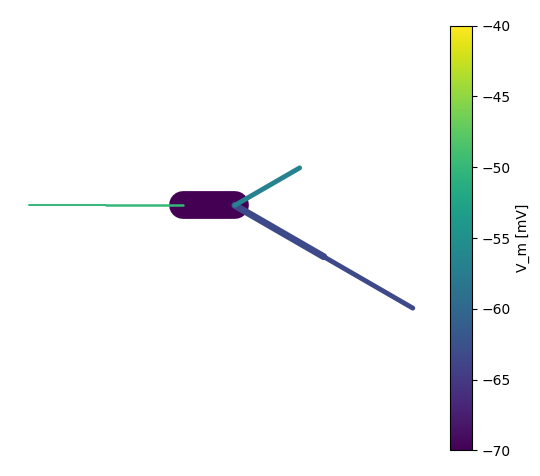

In [ ]:
n_branches = len(tree.branches)
voltage = np.linspace(-70.0, -50.0, n_branches) * u.mV

fig, ax = plt.subplots(figsize=(5.5, 5))
vis.plot2d(
    tree,
    values=voltage,
    cmap='viridis',
    vmin=-70,
    vmax=-40,
    value_label='V_m',
    shape='line',
    ax=ax,
)
fig.tight_layout()

## 5. Overlays — regions and locsets

Regions (highlight strokes) and locsets (markers) are rendered as overlays
on top of the base tree. Build them with `RegionExpr` / `LocsetExpr`,
evaluate them on the morphology, and pass the masks directly.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


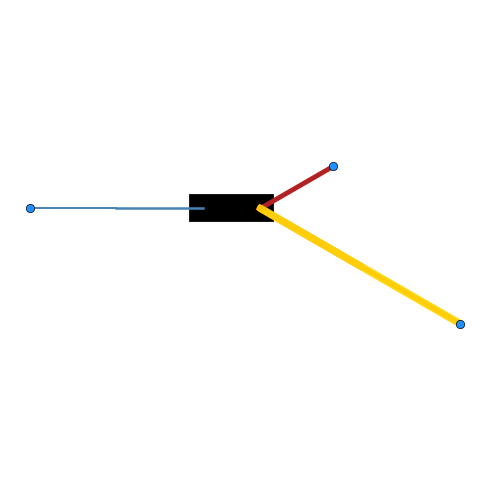

In [ ]:
from braincell.filter import BranchInFilter, Terminals

region_mask = BranchInFilter('type', 'apical_dendrite').evaluate(tree)
locset_mask = Terminals().evaluate(tree)

fig, ax = plt.subplots(figsize=(5, 5))
vis.plot2d(
    tree,
    region=region_mask,
    locset=locset_mask,
    shape='line',
    ax=ax,
)
fig.tight_layout()

## 6. `plot_movie` — time-varying values

Given a `(n_frames, n_branches)` array of scalars per branch, `plot_movie`
builds the scene once and mutates the `LineCollection` scalar array per
frame. The returned `MovieResult` holds the matplotlib `FuncAnimation`
handle; assign it to a variable or save to `.gif` / `.mp4` via `out=...`.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


frames = 30


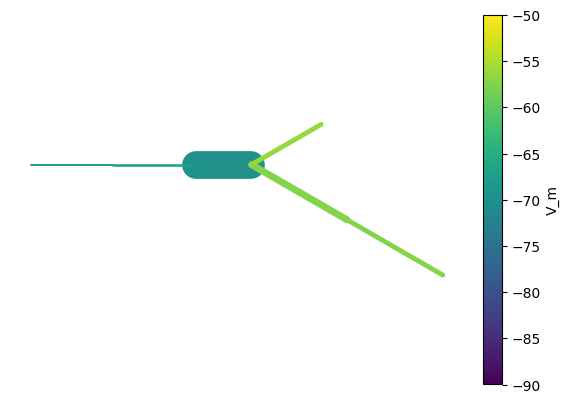

In [ ]:
n_frames = 30
values_t = np.stack([
    -70.0 + 15.0 * np.sin(2 * np.pi * i / n_frames + np.arange(n_branches))
    for i in range(n_frames)
])

result = vis.plot_movie(
    tree,
    values_t,
    dimensionality='2d',
    shape='line',
    cmap='viridis',
    vmin=-90,
    vmax=-50,
    value_label='V_m',
)
anim = result.animation
print(f'frames = {result.frames}')

## 7. `plot_traces` — morphology + time-series panels

`plot_traces` stacks per-location time-series next to a morphology view
with matching markers. Pass a `locset` mask to pick the probe locations
and a `(n_time, n_locs)` array of recordings.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


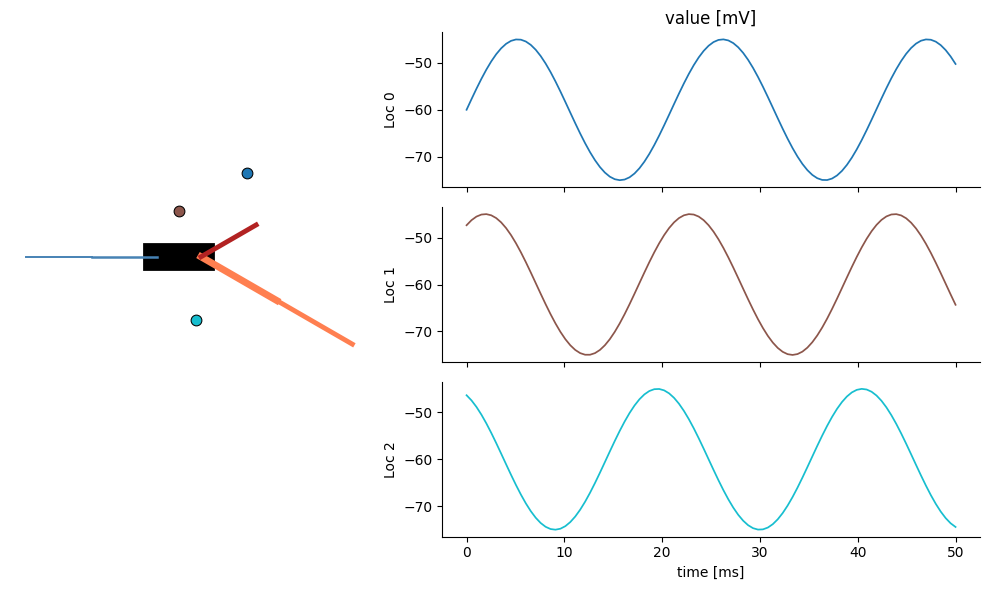

In [ ]:
from braincell.filter import Terminals

locset_mask = Terminals().evaluate(tree)
n_locs = len(locset_mask.points)
t = np.linspace(0, 50, 100) * u.ms
traces = np.sin(
    (t.to_decimal(u.ms))[:, None] * 0.3 + np.arange(n_locs)[None, :]
) * 15 - 60
traces = traces * u.mV

result = vis.plot_traces(
    tree,
    t,
    traces,
    locset=locset_mask,
    shape='line',
)
result.figure.tight_layout()

## 8. Morphometry plots

Four standard morphometric plots are available:

* `plot_dendrogram` — ordered left-to-right tree schematic.
* `plot_topology` — depth-indexed connectivity, lengths ignored.
* `plot_sholl` — Sholl intersection profile with optional `center` override.
* `plot_branch_order_histogram` — branches per depth level.

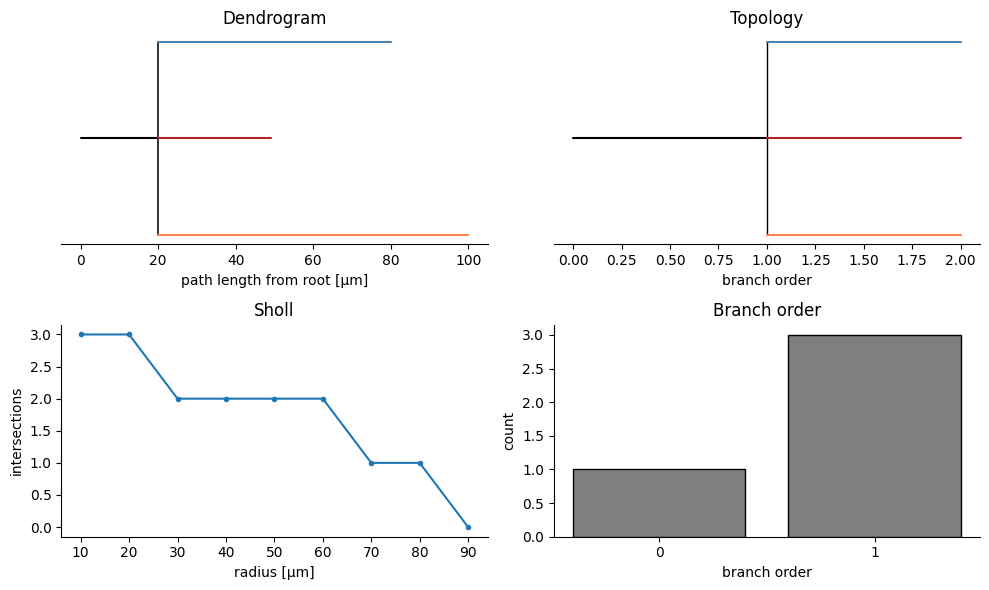

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
vis.plot_dendrogram(tree, ax=axes[0, 0])
axes[0, 0].set_title('Dendrogram')
vis.plot_topology(tree, ax=axes[0, 1])
axes[0, 1].set_title('Topology')
vis.plot_sholl(tree, ax=axes[1, 0], step_um=10.0)
axes[1, 0].set_title('Sholl')
vis.plot_branch_order_histogram(tree, ax=axes[1, 1])
axes[1, 1].set_title('Branch order')
fig.tight_layout()

## 9. Interactivity — `VisHooks`

`VisHooks(on_pick=..., on_hover=..., on_leave=...)` wires interactive
callbacks. Clicking a branch in matplotlib receives a `PickInfo` payload
with `branch_index`, `branch_name`, `segment_index`, `x`, `value`, and
the raw artist. The PyVista backend mirrors `on_pick` via
`enable_point_picking`.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Interactive figure ready. In a notebook with an interactive backend,
click a branch to populate `picked` with PickInfo records.


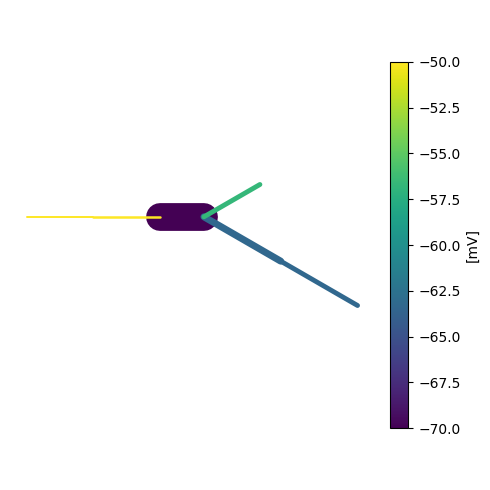

In [ ]:
picked = []

def on_pick(info):
    picked.append(info)
    print(f'picked branch={info.branch_name!r} segment={info.segment_index} value={info.value}')

fig, ax = plt.subplots(figsize=(5, 5))
vis.plot2d(
    tree,
    values=voltage,
    cmap='viridis',
    shape='line',
    ax=ax,
    hooks=vis.VisHooks(on_pick=on_pick),
)
fig.tight_layout()
print('Interactive figure ready. In a notebook with an interactive backend,')
print('click a branch to populate `picked` with PickInfo records.')

## 10. Publication export

`publication_theme()` flips branch colours, alphas, and matplotlib
`rcParams` to a publication-ready preset. `save_figure` is a unified
saver that dispatches on the backend return value (matplotlib `Axes` or
`Figure`, pyvista `Plotter`, plotly `Figure`).

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


wrote vis_outputs/publication.pdf


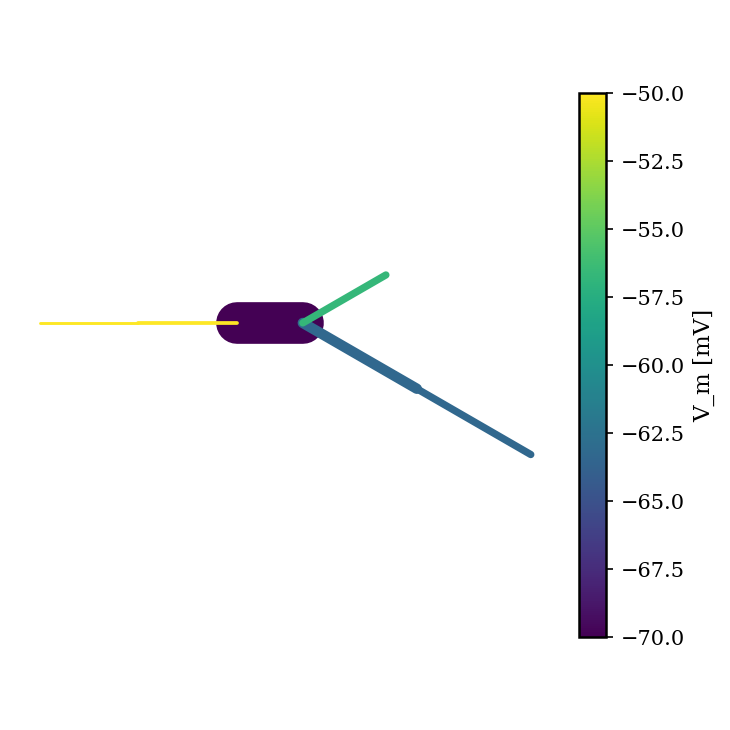

In [ ]:
from pathlib import Path

out_dir = Path('vis_outputs')
out_dir.mkdir(exist_ok=True)

with vis.publication_theme():
    fig, ax = plt.subplots(figsize=(5, 5))
    vis.plot2d(
        tree,
        values=voltage,
        cmap='viridis',
        value_label='V_m',
        shape='line',
        ax=ax,
    )
    fig.tight_layout()
    vis.save_figure(ax, out_dir / 'publication.pdf', dpi=300)
print('wrote', out_dir / 'publication.pdf')

## 11. Comparing morphologies and values

`compare_morphologies` renders several morphologies side by side with a
shared layout. `compare_values` does the same for multiple value arrays
on a single morphology — handy for before/after simulations.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


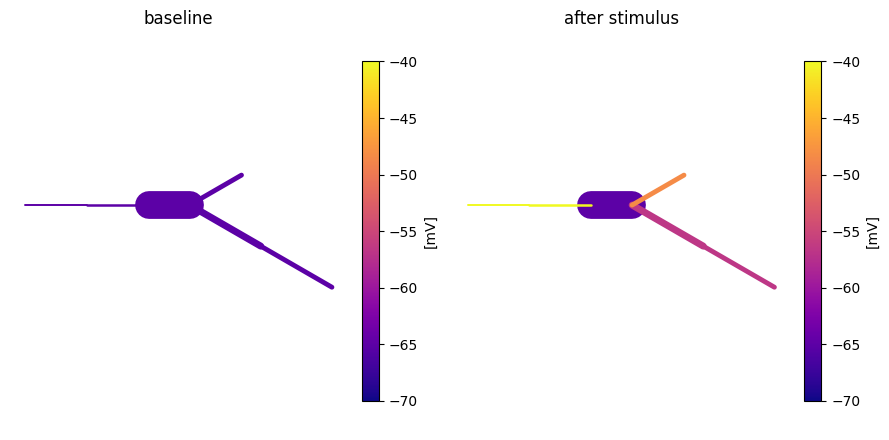

In [ ]:
v_baseline = np.full(n_branches, -65.0) * u.mV
v_after = np.linspace(-65.0, -40.0, n_branches) * u.mV

fig, axes = vis.compare_values(
    tree,
    [v_baseline, v_after],
    titles=['baseline', 'after stimulus'],
    cmap='plasma',
    vmin=-70,
    vmax=-40,
    shape='line',
)
fig.tight_layout()